# 0. 環境構築

In [2]:
#!uv add -q matplotlib pymc numpy pandas arviz seaborn japanize-matplotlib

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import numpy as np
import pandas as pd
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

%matplotlib inline

g++ not available, if using conda: `conda install gxx`


# 1. 一様分布
- 一様分布とは、ある範囲内のすべての値が等しい確率で生起する確率分布
- ベイズ統計では弱事前分布として使用されることが多い 

Text(0.5, 1.0, 'Uniform Distribution')

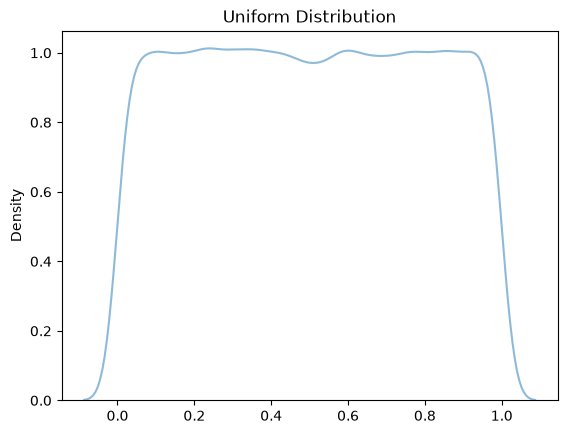

In [4]:
sns.kdeplot(x=pm.Uniform.dist(lower=0, upper=1, size=100000).eval(), alpha=0.5)
plt.title("Uniform Distribution")

# 2. 半正規分布

- 非負値をとる数値の分布。非負のみをとることから、正規分布（`μ`, `σ`）の `σ` に関する事前分布として用いられることが多い。

Text(0.5, 1.0, 'Half-Normal Distributions')

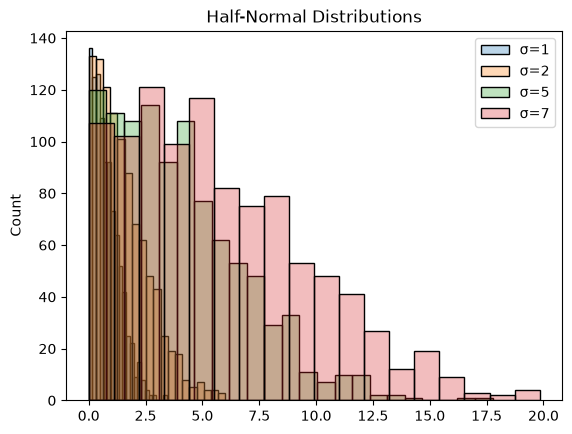

In [5]:
sigmas = [1, 2, 5, 7]

for sigma in sigmas:
    sns.histplot(x=pm.HalfNormal.dist(mu=0, sigma=sigma, size=1000).eval(), label=f"σ={sigma}", fill=True, alpha=0.3)
plt.legend()
plt.title("Half-Normal Distributions")

# 3. ポワソン分布
https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.Poisson.html
- ポワソン分布は離散分布となり、めったに起きないカウントデータの生起確率を示す。
- ポワソン分布は **平均 = 分散** となる特徴があり、分散 > 平均（過分散） となるようなケースでは負の二項分布に拡張する必要がある。
- 単位時間（または単位空間）あたりに平均して $\lambda$ 回発生する事象が、その期間内にちょうど $k$ 回発生する確率は以下の式で表されます。
- ポワソン回帰では確率分布に使用され、 $\lambda$ のリンク関数としては **対数リンク関数** が使用されることが多い。（※ $\lambda$ は非負かつ値が小さいことが多いため）



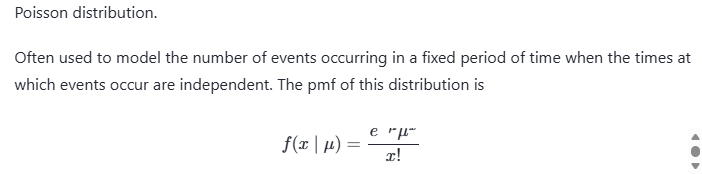

Text(0.5, 1.0, 'Poisson Distributions')

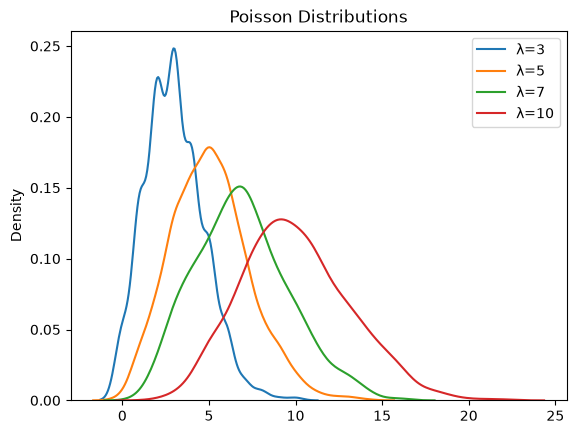

In [6]:
lamdas = [3, 5, 7, 10]

[sns.kdeplot(x=pm.Poisson.dist(mu=lamda, size=1000).eval(), label=f"λ={lamda}") for lamda in lamdas]
plt.legend()
plt.title("Poisson Distributions")

# 4. 二項分布
https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.Binomial.html
- 成功確率：$p$ , 試行回数：$n$ に対して、$X$回成功が出る確率
- $n$ → $∞$ で正規分布に近似

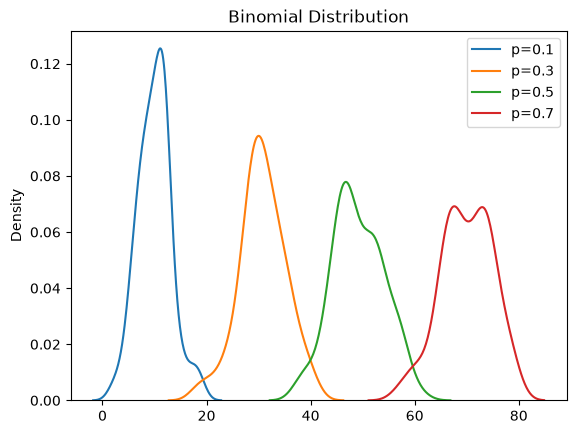

In [7]:
pars = [0.1, 0.3, 0.5, 0.7]

[sns.kdeplot(x=pm.Binomial.dist(n=100, p=p, size=100).eval(), label=f"p={p}") for p in pars]
plt.title("Binomial Distribution")
plt.legend()

# 5. 負の二項分布
https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.NegativeBinomial.html

- ポワソン分布とガンマ分布の混合分布（ガンマ分布における強度 $\lambda$ がガンマ分布に従う確率変数で定義される）
- 負の二項分布が持つ平均 $\mu$ とポワソン分布が持つ強度 $\lambda$ は意味合い的には同じ。
- 負の二項分布では パラメータ $\alpha$ を導入し、ポワソン分布における **平均=分散** の制約を解いている。
- 例えば下図では、 ポワソン分布と負の二項分布を比較し、負の二項分布における $\alpha$ が十分大きい値をとる場合 $\mu=\lambda$ に漸近する様子を示す。

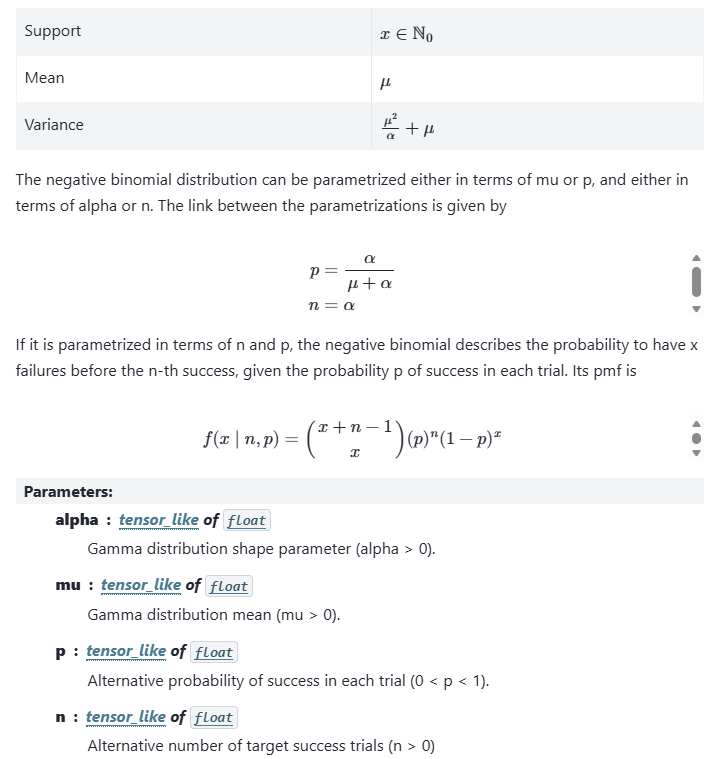

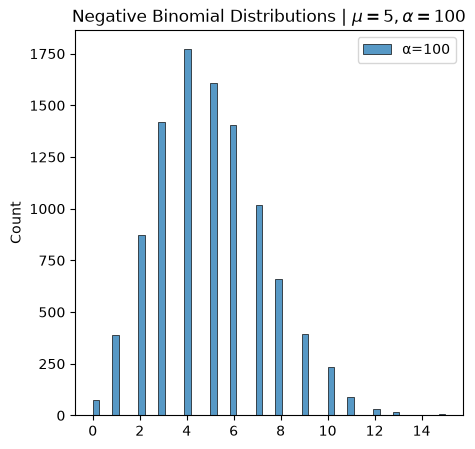

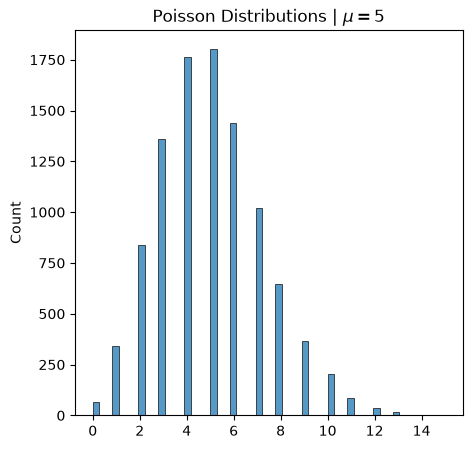

In [8]:
"""
負の二項分布では lambda が大きくなると、ポアソン分布に近似されることが知られている。
ここでは、負の二項分布のパラメータ α を 100 に設定し、ポアソン分布と比較。
分散を大きくしたい場合は、α を小さくすることで分散を大きくすることができる。
"""
alphas = [100]

fig, ax = plt.subplots(figsize=(5, 5))
[sns.histplot(x=pm.NegativeBinomial.dist(mu=5, alpha=alpha, size=10000).eval(), label=f"α={alpha}") for alpha in alphas]
plt.legend()
plt.title(f"Negative Binomial Distributions | $μ=5, α=100$");

fig, ax = plt.subplots(figsize=(5, 5))
sns.histplot(x=pm.Poisson.dist(mu=5, size=10000).eval(), label="Poisson")
plt.title("Poisson Distributions | $μ=5$");

# 6. 指数分布
- 指数分布は、「ある出来事が起こるまでの待ち時間」を表す連続分布
- **確率変数 $X$ は λ が与えれた時の<待ち時間>を示す。**
- ここでパラメータ λ は rate と呼ばれる。
- λ は「どれくらい頻繁にイベントが起こるか」
    - λ が大きい → イベントが頻繁に起こる → 待ち時間は短い
    - λ が小さい → イベントがまれにしか起こらない → 待ち時間は長い
- 平均待ち時間は 1/λ

https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.Exponential.html

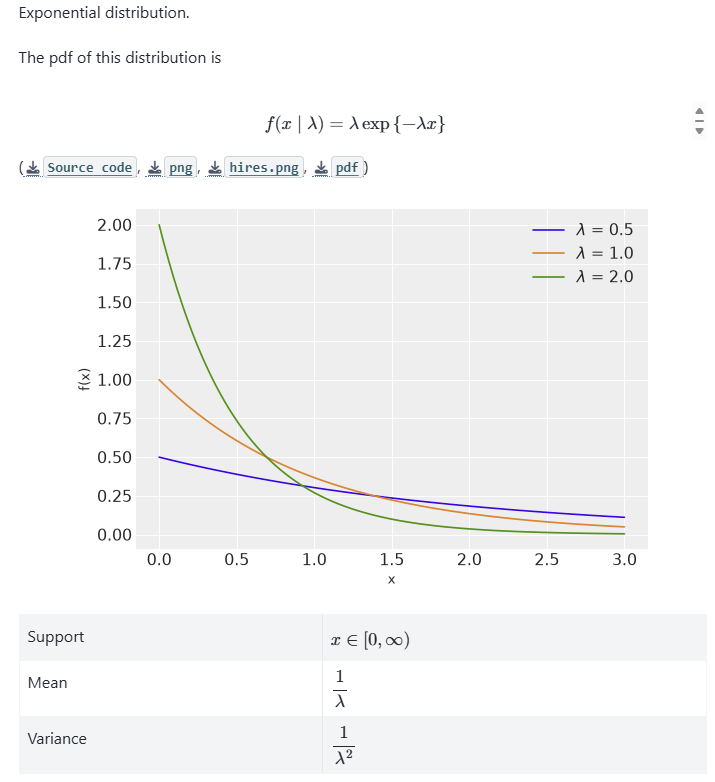

例1：コンビニにお客さんが来る頻度（ポアソン過程と指数分布）単位時間あたりの平均来店数を $\lambda$（平均来店頻度） とすると、指数分布によって 「次のお客さんが来るまでの待ち時間」 の期待値を求めることができます。
- 1. 混雑している店（イベントが頻繁）条件: 1分に平均 2 人来る ($\lambda = 2$)平均待ち時間:$$\frac{1}{\lambda} = \frac{1}{2} \text{分} = \text{\textbf{30秒}}$$
- 2. 閑散としている店（イベントが稀）条件: 1分に平均 0.2 人しか来ない ($\lambda = 0.2$)平均待ち時間:$$\frac{1}{\lambda} = \frac{1}{0.2} \text{分} = \text{\textbf{5分}}$$
    - **要点のまとめ**
        - $\lambda$: 「どれくらい忙しい店か」 を表す指標（単位時間あたりの発生頻度）
        - 指数分布: その店における 「次のお客さんが来るまでの待ち時間」 を表す確率分布

Text(0.5, 1.0, 'Exponential Distribution')

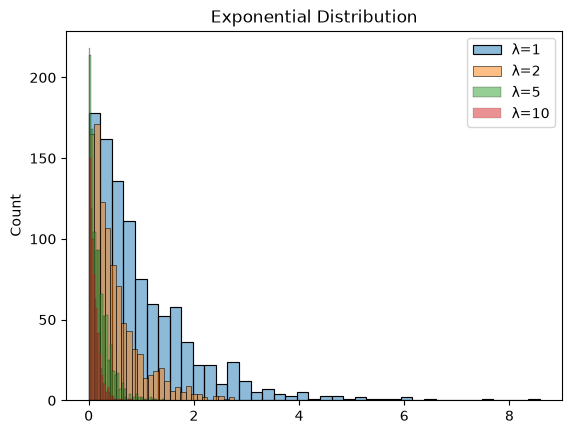

In [9]:
lambdas = [1, 2, 5, 10]

[sns.histplot(x=pm.Exponential.dist(lam=lam, size=1000).eval(), label=f"λ={lam}", alpha=0.5) for lam in lambdas]
plt.legend()
plt.title("Exponential Distribution")

# 7. ガンマ分布
- 指数分布は「次の出来事が起こるまでの待ち時間」を表すのに対して、ガンマ分布は「出来事が何回か起こるまでの総待ち時間」を表します。

例:コールセンターに電話が来る場合を考えます。
平均して1時間に2件の電話が来るとします。

- 到着率（rate）: $\beta = 2$
- 1件の電話を待つ時間 → 指数分布

では、3件目の電話が来るまでの時間を知りたい場合はどうでしょうか。

これは

$$
X \sim \mathrm{Gamma}(\alpha = 3,\ \beta = 2)
$$

で表せます。

なぜなら、

- 1件目まで待つ時間
- 2件目まで待つ時間
- 3件目まで待つ時間

の合計だからです。

ガンマ分布は

「$\alpha$ 個の指数分布の和」

として表されます。

したがって、この例では

$$
\alpha = 3
$$

です。

https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.Gamma.html

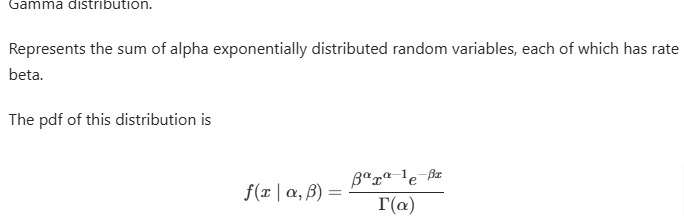

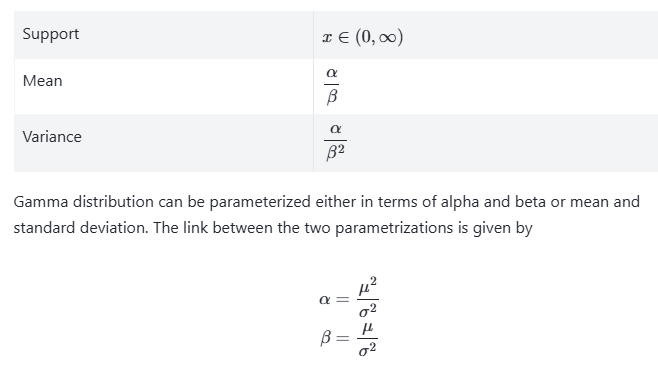

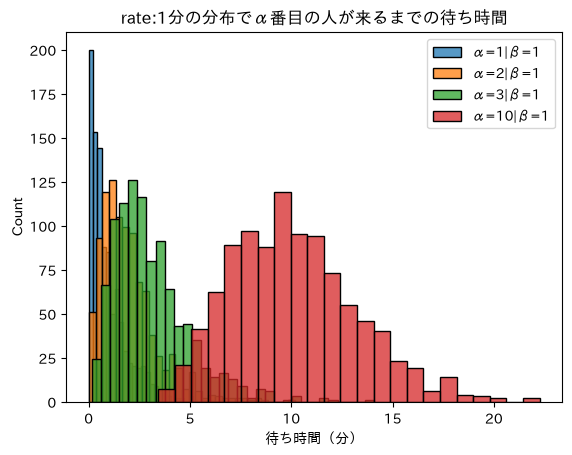

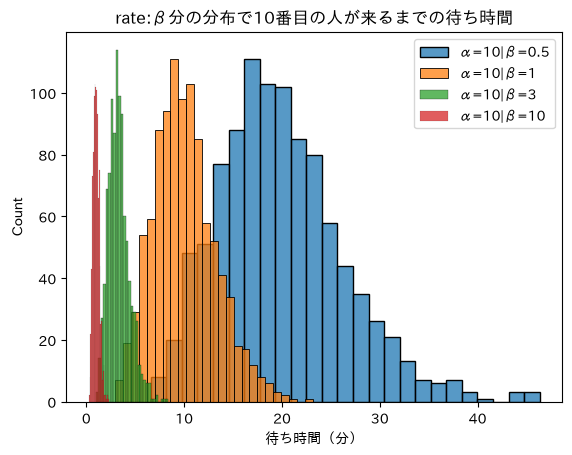

In [10]:
#------------------------------------------------------------------
# alpha（n番目の事象が起こるパラメータ）を変化させ、待ち時間の分布変化を見る
#------------------------------------------------------------------
import japanize_matplotlib

alphas = [1, 2, 3, 10]
beta = 1

[sns.histplot(pm.Gamma.dist(alpha=alpha, beta=beta, size=1000).eval(), label=f'α={alpha}|β={beta}') for alpha in alphas]
plt.xlabel("待ち時間（分）")
plt.ylabel("Count")
plt.legend()
plt.title(f"rate:{beta}分の分布でα番目の人が来るまでの待ち時間")
plt.show()


#------------------------------------------------------------------------
# β（rateパラメータ）を変化させ、同じ番目でも待つ時間がどれくらい変わるかを見る
#------------------------------------------------------------------------
alpha = 10
betas = [0.5, 1, 3, 10]

[sns.histplot(x=pm.Gamma.dist(alpha=10, beta=beta, size=1000).eval(), label=f"α={alpha}|β={beta}") for beta in betas]
plt.xlabel("待ち時間（分）")
plt.ylabel("Count")
plt.legend()
plt.title(f"rate:β分の分布で{alpha}番目の人が来るまでの待ち時間")
plt.show()


beta（rate）が大きくなるほど、分散が小さくなり分布も正規分布に近似される例（X>0）

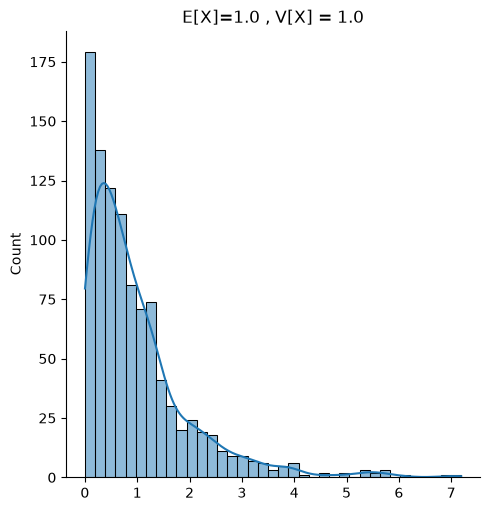

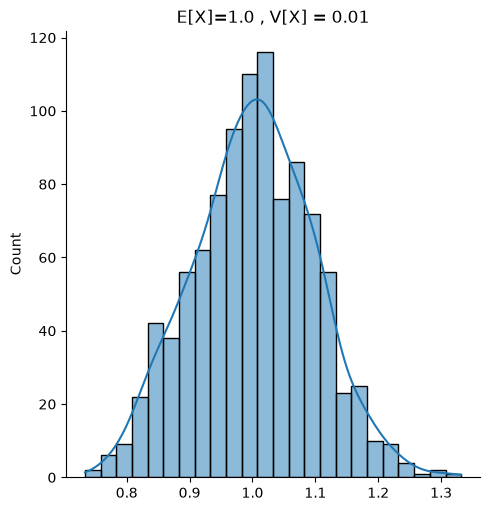

In [25]:
sns.displot(pm.Gamma.dist(alpha=1, beta=1, size=1000).eval(), kde=True)
plt.title(f"E[X]={1/1} , V[X] = {1/1**2}")
plt.show()

sns.displot(pm.Gamma.dist(alpha=100, beta=100, size=1000).eval(), kde=True)
plt.title(f"E[X]={100/100} , V[X] = {100/100**2}")
plt.show()

# 8. β分布
- 成功回数:α, 失敗回数:β を観測した際の 成功確率 P を確率変数とする分布

https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.Beta.html

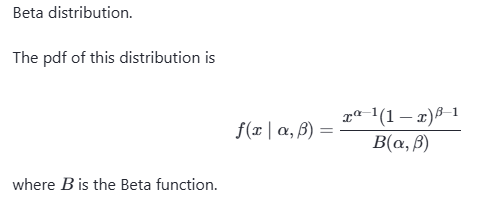

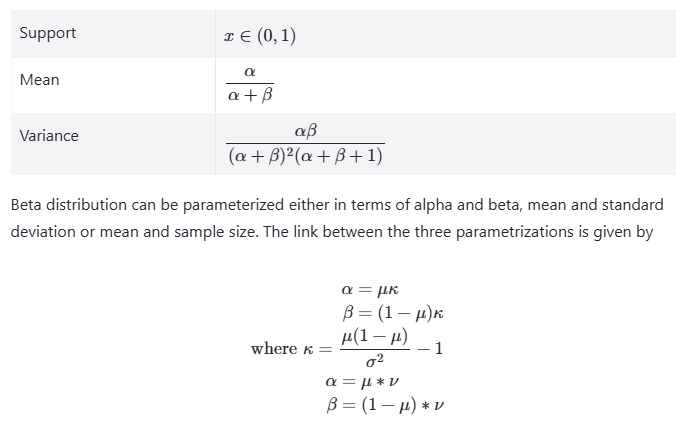

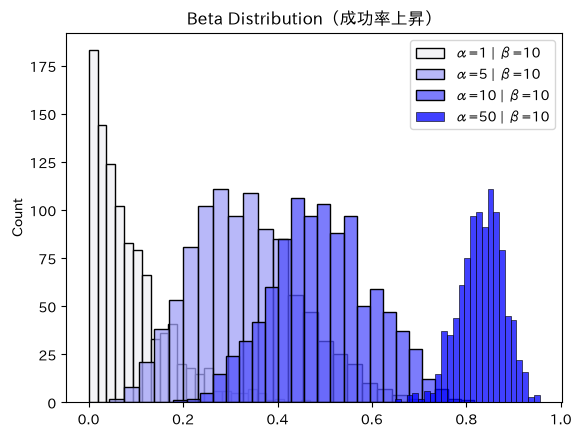

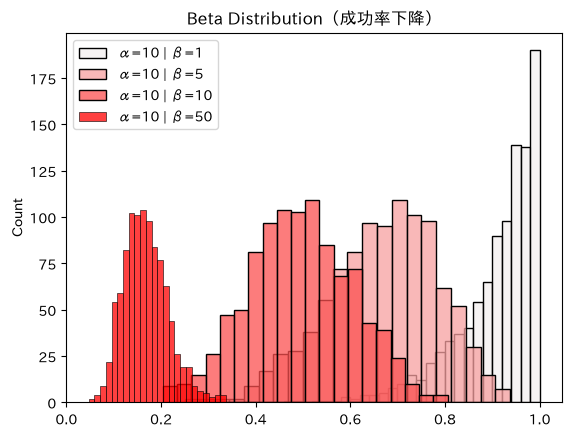

In [11]:
#-----------------------------------------------------
# 成功回数:αが増え、成功確率の分布が右に偏っていく様子
#-----------------------------------------------------
alphas = [1, 5, 10, 50]
beta = 10
sns.set_palette(sns.light_palette("blue", n_colors=len(alphas)))
[sns.histplot(x=pm.Beta.dist(alpha=alpha, beta=beta, size=1000).eval(), label=f"α={alpha} | β={beta}") for alpha in alphas]
plt.legend()
plt.title(f"Beta Distribution（成功率上昇）")
plt.show();

#-----------------------------------------------------
# 失敗回数:βが増え、成功確率の分布が左に偏っていく様子
#-----------------------------------------------------
alpha = 10
betas = [1, 5, 10, 50]
sns.set_palette(sns.light_palette("red", n_colors=len(betas)))
[sns.histplot(x=pm.Beta.dist(alpha=alpha, beta=beta, size=1000).eval(), label=f"α={alpha} | β={beta}") for beta in betas]
plt.legend()
plt.title(f"Beta Distribution（成功率下降）")
plt.show();

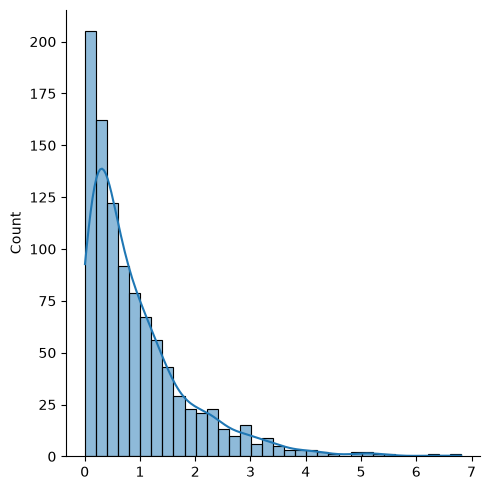

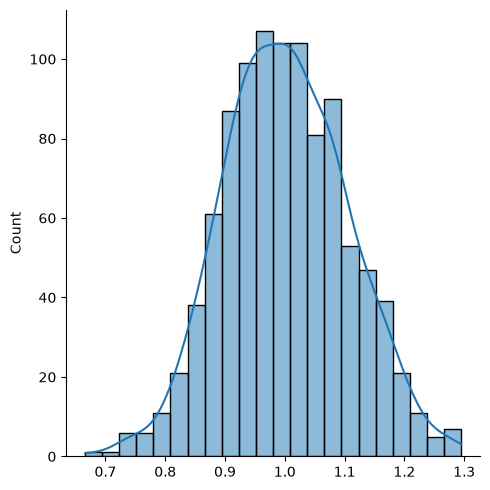